<a href="https://colab.research.google.com/github/yashdeepspodder23/BlackHoleSimulations/blob/main/BHSim4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_772/3748508534.py:121: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  horizon_sphere = plt.Circle(bh_pos, Rs, color='#080808', edgecolor='#e74c3c', lw=2, zorder=2, label='Event Horizon ($R_s = 2M$)')


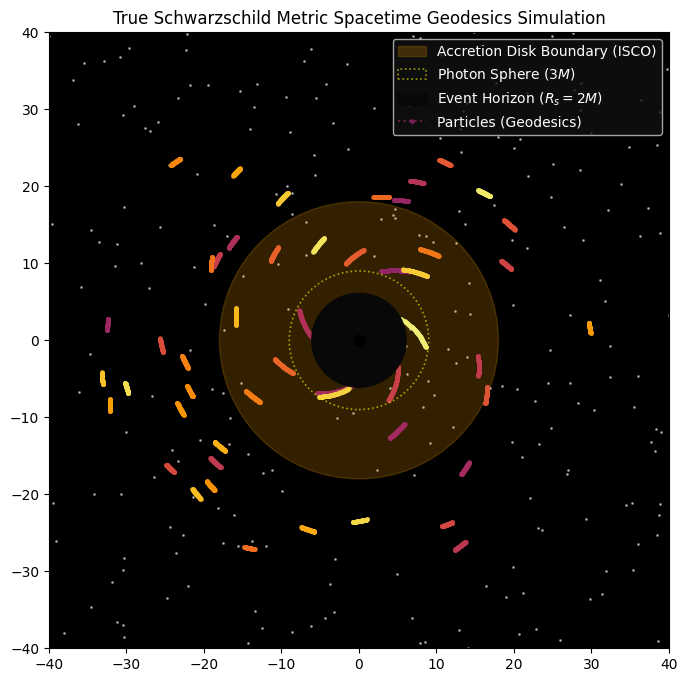

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import collections

# =====================================================================
# CONSTANTS & SCHWARZSCHILD RELATIVISTIC PARAMETERS
# =====================================================================
G = 1        # Gravitational constant
M = 3.0      # Mass of the black hole (scaled for smooth visualization)
dt = 0.075    # Time step (proper time increment d_tau)
num_p = 50   # Number of particles

# Exact Schwarzschild properties
c = 1.0                  # Speed of light in geometrized units
Rs = (2.0 * G * M) / c**2 # Event Horizon (Schwarzschild Radius) = 4.0
R_photon = 1.5 * Rs      # Photon Sphere = 6.0
R_isco = 3.0 * Rs        # Innermost Stable Circular Orbit = 12.0

# Initialize particle positions and velocities
np.random.seed(105)

# For a stable simulation using true GR geodesics, we initialize state vectors
# in polar coordinates: [r, phi, vr, vphi]
# We spawn them outside the ISCO and give them tangential velocity
poss_polar = np.zeros((num_p, 4))
poss_polar[:, 0] = np.random.uniform(13.0, 35.0, num_p)   # Initial radius 'r'
poss_polar[:, 1] = np.random.uniform(0, 2 * np.pi, num_p)  # Initial angle 'phi'
poss_polar[:, 2] = np.random.uniform(-0.1, 0.1, num_p)     # Initial radial velocity 'vr'

# Calculate specific angular momentum to provide realistic curved trajectories
for i in range(num_p):
    r_init = poss_polar[i, 0]
    # Keplerian angular velocity approximation for initialization baseline
    vphi_init = np.sqrt(G * M / r_init**3) * np.random.uniform(0.8, 1.2)
    poss_polar[i, 3] = vphi_init

# Map initial Cartesian coordinates for matching your code setup
poss = np.zeros((num_p, 2))
for i in range(num_p):
    poss[i, 0] = poss_polar[i, 0] * np.cos(poss_polar[i, 1])
    poss[i, 1] = poss_polar[i, 0] * np.sin(poss_polar[i, 1])

# Black hole position
bh_pos = np.array([0, 0])

# Global variables for trail
trail_length = 60
trail_data = [collections.deque(maxlen=trail_length) for _ in range(num_p)]

# =====================================================================
# SCHWARZSCHILD GEODESIC EQUATIONS OF MOTION
# =====================================================================
def schwarzschild_geodesic_derivatives(state):
    r, phi, vr, vphi = state

    if r <= Rs:
        return np.array([0.0, 0.0, 0.0, 0.0])

    # Conserved angular momentum per unit mass: L = r^2 * d_phi/d_tau
    L = (r**2) * vphi

    # GR Geodesic Equation: d_vr/d_tau = -GM/r^2 + L^2/r^3 - 3GML^2/(c^2 * r^4)
    d_vr = - (G * M) / r**2 + (L**2) / r**3 - (3.0 * G * M * L**2) / (c**2 * r**4)
    d_r = vr
    d_phi = vphi
    d_vphi = - (2.0 * vr * vphi) / r  # Relativistic conservation of momentum constraint

    return np.array([d_r, d_phi, d_vr, d_vphi])

# Update particle positions via Runge-Kutta 4th Order (RK4) integration for GR stability
def update_particles_gr(poss_polar, poss):
    for i in range(len(poss_polar)):
        r = poss_polar[i, 0]

        if r <= Rs:
            # Trapped inside the event horizon: Particle crushed to the origin
            poss_polar[i, :] = np.array([0.0, 0.0, 0.0, 0.0])
            poss[i] = np.array([0.0, 0.0])
            continue

        # RK4 Integration steps
        y = poss_polar[i]
        k1 = schwarzschild_geodesic_derivatives(y)
        k2 = schwarzschild_geodesic_derivatives(y + 0.5 * dt * k1)
        k3 = schwarzschild_geodesic_derivatives(y + 0.5 * dt * k2)
        k4 = schwarzschild_geodesic_derivatives(y + dt * k3)

        poss_polar[i] += (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

        # Unpack updated polar metrics and translate to your Cartesian plotting array
        new_r, new_phi = poss_polar[i, 0], poss_polar[i, 1]
        poss[i, 0] = new_r * np.cos(new_phi)
        poss[i, 1] = new_r * np.sin(new_phi)

    return poss_polar, poss

# =====================================================================
# PLOT SETUP & SPACE LAYERING
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-40, 40)
ax.set_ylim(-40, 40)
ax.set_facecolor('black')

# Static background stars
num_stars = 250
star_x = np.random.uniform(-40, 40, num_stars)
star_y = np.random.uniform(-40, 40, num_stars)
ax.scatter(star_x, star_y, s=1, color='white', alpha=0.5, zorder=0)

# Accretion Disk styled inside the Innermost Stable Circular Orbit (ISCO)
accretion_disk = plt.Circle(bh_pos, R_isco, color='orange', alpha=0.2, zorder=1, label='Accretion Disk Boundary (ISCO)')
ax.add_patch(accretion_disk)

# Add the Unstable Photon Sphere Ring
photon_ring = plt.Circle(bh_pos, R_photon, color='yellow', fill=False, linestyle=':', lw=1.2, alpha=0.6, zorder=1.8, label='Photon Sphere ($3M$)')
ax.add_patch(photon_ring)

# True Schwarzschild Event Horizon Patch
horizon_sphere = plt.Circle(bh_pos, Rs, color='#080808', edgecolor='#e74c3c', lw=2, zorder=2, label='Event Horizon ($R_s = 2M$)')
ax.add_patch(horizon_sphere)

# Singularity
bh = plt.scatter(*bh_pos, color='black', s=60, zorder=3)

# Build trail objects
particles_trails = []
colors = plt.cm.inferno(np.linspace(0.4, 0.95, num_p)) # Highly luminous relativistic styling
for i in range(num_p):
    if i == 0:
        line, = ax.plot([], [], 'o:', color=colors[i], markersize=2.5, alpha=0.7, label='Particles (Geodesics)', zorder=1.5)
    else:
        line, = ax.plot([], [], 'o:', color=colors[i], markersize=2.5, alpha=0.7, zorder=1.5)
    particles_trails.append(line)

ax.legend(loc='upper right', facecolor='#111111', labelcolor='white')
plt.title('True Schwarzschild Metric Spacetime Geodesics Simulation', color='black')

# =====================================================================
# ANIMATION LOOP
# =====================================================================
def init():
    for line in particles_trails:
        line.set_data([], [])
    return particles_trails

def animate(frame):
    global poss_polar, poss
    poss_polar, poss = update_particles_gr(poss_polar, poss)

    for i in range(num_p):
        # Freeze trail tracking instantly if particle hits the singularity
        if not np.all(poss[i] == 0.0):
            trail_data[i].append(poss[i].copy())

    artists_to_return = []
    for i, line in enumerate(particles_trails):
        x_coords = [p[0] for p in trail_data[i]]
        y_coords = [p[1] for p in trail_data[i]]
        line.set_data(x_coords, y_coords)
        artists_to_return.append(line)

    return artists_to_return

ani = FuncAnimation(fig, animate, frames=500, init_func=init, interval=25, blit=True)
#plt.show()

from IPython.display import HTML
html_animation = HTML(ani.to_html5_video())
display(html_animation)